令和7年度の榊原和哉の卒業研究（特別研究）論文「フードバンクにおける食料分配手法の学習不安定性に関する一考察」の4.2節で示した、 Mixing Network の重み・バイアスの分布を観察するために使用したコードです。

wandbのログにテーブルとして記録された各項目を取得し、それらの分布をヒストグラムとバイオリンプロットに起こします。対象となるrunの情報はクラウド上のプロジェクトから取得しますが、テーブルの内容は高速化のためにローカルのwandbログから取得しています。それでも集計処理に何分か掛かるため、データ取得と集計までで1セル、結果の描画は別セルとしています。


In [2]:
import wandb
import pandas as pd
import glob
import json


entity = "kazuyasakakibara"
project = "FoodBank2025"

api = wandb.Api()

w1_values_with_timeout = pd.DataFrame()
b1_values_with_timeout = pd.DataFrame()
w_final_values_with_timeout = pd.DataFrame()
v_values_with_timeout = pd.DataFrame()

w1_values_without_timeout = pd.DataFrame()
b1_values_without_timeout = pd.DataFrame()
w_final_values_without_timeout = pd.DataFrame()
v_values_without_timeout = pd.DataFrame()

def load_table(run_dir, path):
    table_json_path = f"{run_dir}/files/{path}"
    with open(table_json_path, 'r') as f:
        data = json.load(f)
        table_df = pd.DataFrame(data=data["data"], columns=data["columns"])
    return table_df

runs = api.runs(f"{entity}/{project}", filters={
    "created_at": {"$gte": "2025-10-05T00:00:00Z"}, # 10月05日以降
    "state": "finished",
})
print(f"Runs after 2025-10-05: {len(runs)}")

for run in runs[:30]: # 最初の30件だけ処理
    run_id = run.id
    print(f"Processing run_id: {run_id}")
    wandb_run_dir = glob.glob(f"../wandb/run-*_*-{run_id}")[0]
    run = api.run(f"{entity}/{project}/{run_id}")

    try:
        df = run.history(samples=500)[["test_timeout", "w1_table_embed_dim>n_agents", "b1_table", "w_final_table", "v_table"]]
    except KeyError:
        continue
    tables_with_timeout = df[df['test_timeout'].shift() == 1] # Pandas 3.0 以降だと動かないかも
    tables_without_timeout = df[df['test_timeout'].shift() < 1] # Pandas 3.0 以降だと動かないかも

    for index, row in tables_with_timeout.iterrows():
        w1_path = row["w1_table_embed_dim>n_agents"]["path"]
        b1_path = row["b1_table"]["path"]
        w_final_path = row["w_final_table"]["path"]
        v_path = row["v_table"]["path"]

        w1_df = load_table(wandb_run_dir, w1_path)
        b1_df = load_table(wandb_run_dir, b1_path)
        w_final_df = load_table(wandb_run_dir, w_final_path)
        v_df = load_table(wandb_run_dir, v_path)

        w1_values_with_timeout = pd.concat([w1_values_with_timeout, w1_df], ignore_index=True)
        b1_values_with_timeout = pd.concat([b1_values_with_timeout, b1_df], ignore_index=True)
        w_final_values_with_timeout = pd.concat([w_final_values_with_timeout, w_final_df], ignore_index=True)
        v_values_with_timeout = pd.concat([v_values_with_timeout, v_df], ignore_index=True)

    for index, row in tables_without_timeout.iterrows():
        w1_path = row["w1_table_embed_dim>n_agents"]["path"]
        b1_path = row["b1_table"]["path"]
        w_final_path = row["w_final_table"]["path"]
        v_path = row["v_table"]["path"]

        w1_df = load_table(wandb_run_dir, w1_path)
        b1_df = load_table(wandb_run_dir, b1_path)
        w_final_df = load_table(wandb_run_dir, w_final_path)
        v_df = load_table(wandb_run_dir, v_path)

        w1_values_without_timeout = pd.concat([w1_values_without_timeout, w1_df], ignore_index=True)
        b1_values_without_timeout = pd.concat([b1_values_without_timeout, b1_df], ignore_index=True)
        w_final_values_without_timeout = pd.concat([w_final_values_without_timeout, w_final_df], ignore_index=True)
        v_values_without_timeout = pd.concat([v_values_without_timeout, v_df], ignore_index=True)

print("With timeout:")
print("w1 shape:", w1_values_with_timeout.shape)
print("b1 shape:", b1_values_with_timeout.shape)
print("w_final shape:", w_final_values_with_timeout.shape)
print("v shape:", v_values_with_timeout.shape)
print("")
print("Without timeout:")
print("w1 shape:", w1_values_without_timeout.shape)
print("b1 shape:", b1_values_without_timeout.shape)
print("w_final shape:", w_final_values_without_timeout.shape)
print("v shape:", v_values_without_timeout.shape)

Runs after 2025-10-05: 634
Processing run_id: kdxgpyz3
Processing run_id: 5hviojii
Processing run_id: qs0om2h6
Processing run_id: w8yilr6y
Processing run_id: j1d0zlnj
Processing run_id: ad8dq36u
Processing run_id: kq813hut
Processing run_id: 76l9muz5
Processing run_id: zipzcoxx
Processing run_id: y0xkn82k
Processing run_id: y4k3m792
Processing run_id: jzfagqc3
Processing run_id: db8j14ow
Processing run_id: mzqzazct
Processing run_id: caoyxd5y
Processing run_id: kftpig2y
Processing run_id: 5g1hmces
Processing run_id: arjig1oz
Processing run_id: lnqjjr5h
Processing run_id: freeec3v
Processing run_id: crvcls1t
Processing run_id: wox7u2tz
Processing run_id: icyf6uc1
Processing run_id: lka3pqsi
Processing run_id: erht63gl
Processing run_id: 5wr21euw
Processing run_id: vkwcxwp7
Processing run_id: hvrro16f
Processing run_id: pgp6hcmv
Processing run_id: wovzkb5h
With timeout:
w1 shape: (75925, 320)
b1 shape: (75925, 32)
w_final shape: (75925, 32)
v shape: (75925, 1)

Without timeout:
w1 shape:

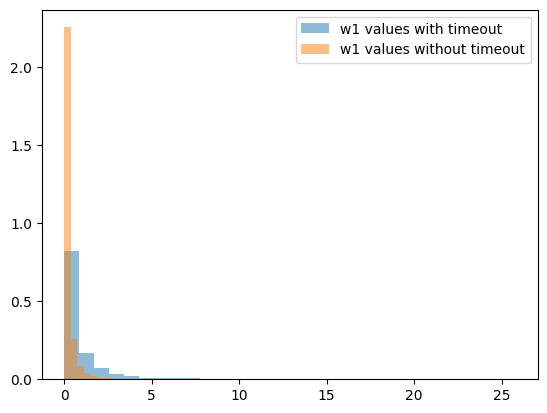

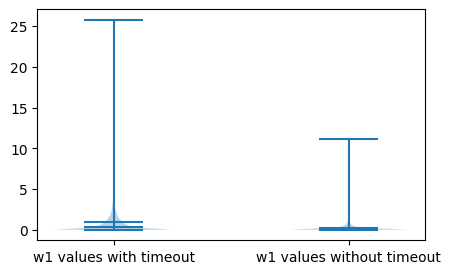

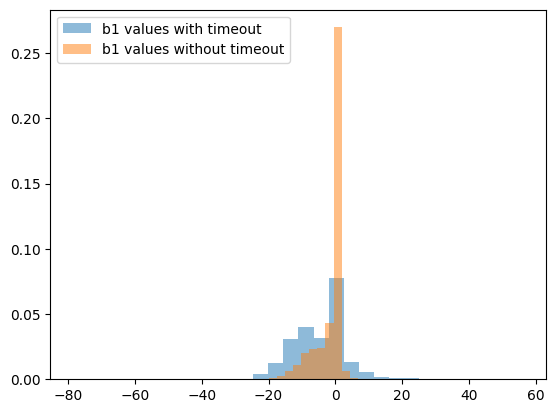

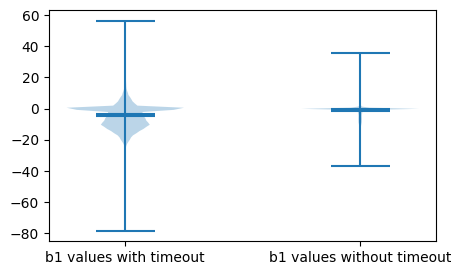

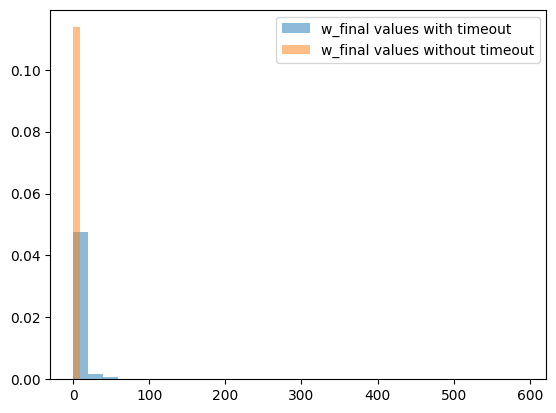

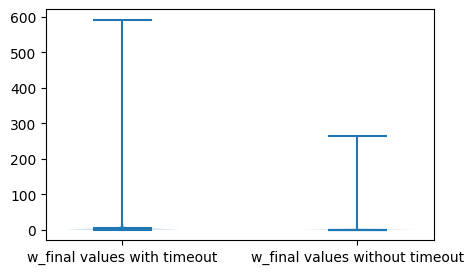

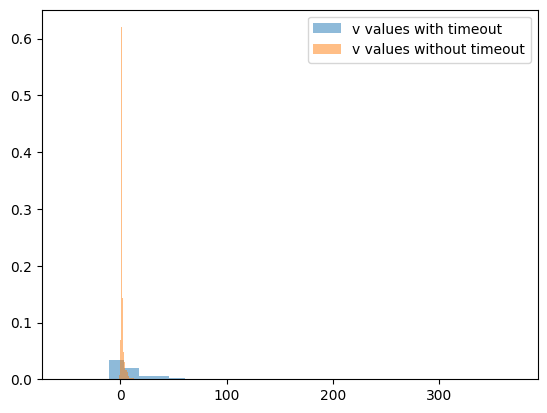

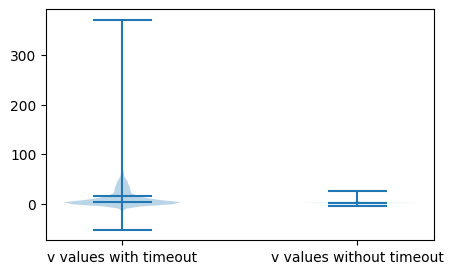

In [3]:
import matplotlib.pyplot as plt


def plot_figures(table_df_with_timeout, table_df_without_timeout, label=""):
    df1_values = table_df_with_timeout.values.flatten()
    df2_values = table_df_without_timeout.values.flatten()

    plt.hist(df1_values, bins=30, density=True, alpha=0.5, label=label + " values with timeout")
    plt.hist(df2_values, bins=30, density=True, alpha=0.5, label=label + " values without timeout")
    # plt.xlim(min(df1_values.min(), df2_values.min()), max(df1_values.max(), df2_values.max()))
    plt.legend()
    plt.show()

    plt.figure(figsize=(5, 3))
    data = [df1_values, df2_values]
    plt.violinplot(data, showmeans=True, showmedians=True)
    plt.xticks([1, 2], [label + " values with timeout", label + " values without timeout"])
    # plt.title(f"Violin plot of {label} values")
    plt.show()

plot_figures(w1_values_with_timeout, w1_values_without_timeout, label="w1")
plot_figures(b1_values_with_timeout, b1_values_without_timeout, label="b1")
plot_figures(w_final_values_with_timeout, w_final_values_without_timeout, label="w_final")
plot_figures(v_values_with_timeout, v_values_without_timeout, label="v")